In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display, Markdown
from matplotlib.patches import Circle, Rectangle
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'DejaVu Sans'  # Поддержка кириллицы
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

%matplotlib inline

# Исходные параметры
r1 = 1.81
r2 = 2.17
x0 = 0.09

ЗАДАНИЕ 1: Логистическое дифференциальное уравнение

Анализ устойчивости к начальным условиям

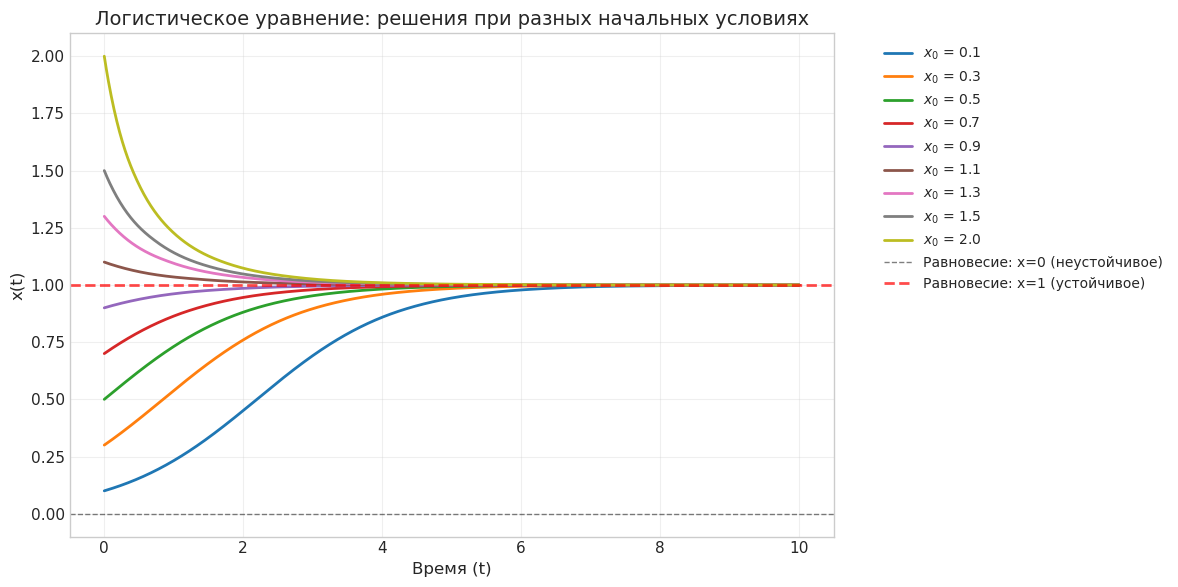

In [2]:
def logistic_diff_eq(t, x, r):
    """Логистическое дифференциальное уравнение: dx/dt = r * x * (1 - x)"""
    return r * x * (1 - x)

display(Markdown("ЗАДАНИЕ 1: Логистическое дифференциальное уравнение"))
display(Markdown("Анализ устойчивости к начальным условиям"))

r = 1.0
t_span = (0, 10)
t_eval = np.linspace(0, 10, 1000)

# Начальные условия: меньше и больше 1
initial_conditions = [0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 2.0]

plt.figure(figsize=(12, 6))

for x0_temp in initial_conditions:
    sol = solve_ivp(logistic_diff_eq, t_span, [x0_temp], args=(r,), t_eval=t_eval)
    label = f'$x_0$ = {x0_temp}'
    plt.plot(sol.t, sol.y[0], linewidth=2, label=label)

# Положения равновесия
plt.axhline(y=0, color='k', linestyle='--', 
            linewidth=1, alpha=0.5, 
            label='Равновесие: x=0 (неустойчивое)')
plt.axhline(y=1, color='r', linestyle='--',
            linewidth=2, alpha=0.7, 
            label='Равновесие: x=1 (устойчивое)')

plt.xlabel('Время (t)', fontsize=12)
plt.ylabel('x(t)', fontsize=12)
plt.title('Логистическое уравнение: решения при разных начальных условиях', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<pre>
ЗАДАНИЕ 2: Преобразования переменных логистического отображения
Исходная форма:
x_{n+1} = (1+r)·x_n - r·x_n²

Шаг 1: Выносим множитель (1+r)
x_{n+1} = (1+r)·[x_n - (r/(1+r))·x_n²]

Шаг 2: Вводим новый параметр R = 1+r, тогда r = R-1
x_{n+1} = R·x_n - (R-1)·x_n²
x_{n+1} = R·x_n·[1 - ((R-1)/R)·x_n]

Шаг 3: Замена переменной y_n = ((R-1)/R)·x_n
Тогда: x_n = (R/(R-1))·y_n
После подстановки и упрощения:
y_{n+1} = R·y_n·(1 - y_n)
→ стандартная форма логистического отображения

Шаг 4: Преобразование к квадратичной форме x_{n+1} = 1 - λ·x_n²
Линейная замена: x_n = a·y_n + b
При a = R/2, b = 1/2 получаем:
y_n = (2x_n - 1)/R
После подстановки:
x_{n+1} = 1 - λ·x_n², где λ = (R² - 2R)/4

Все три формы эквивалентны при соответствующих заменах переменных
</pre>

ЗАДАНИЕ 3: Сравнение непрерывной и дискретной динамики

Параметры: r₁ = 1.81, r₂ = 2.17, x₀ = 0.09


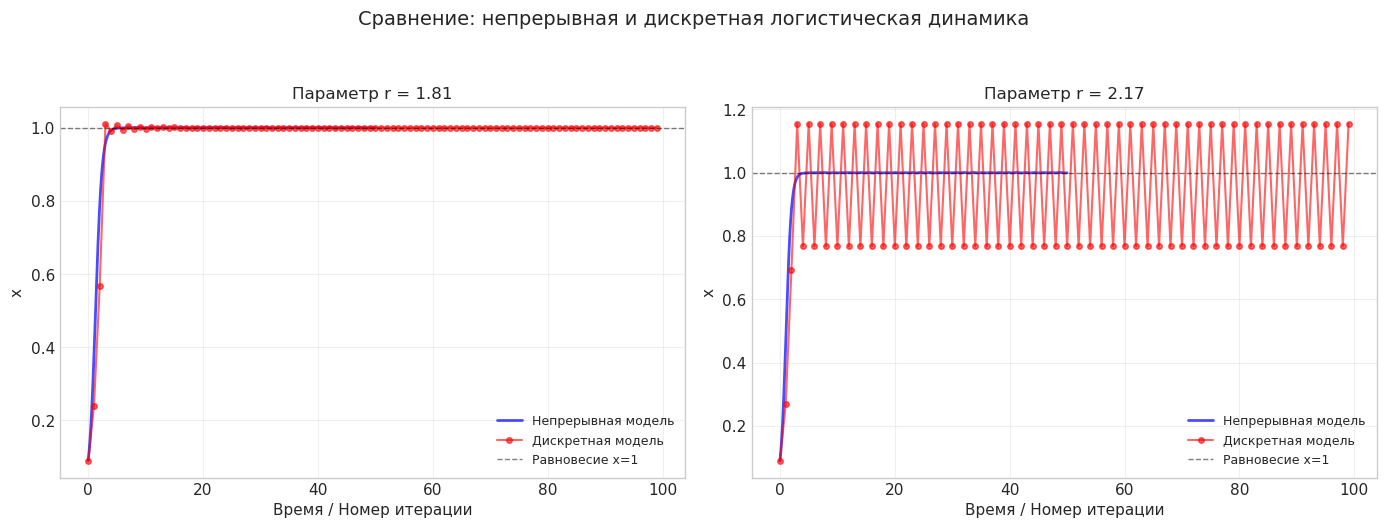


АНАЛИЗ РЕЗУЛЬТАТОВ:

1. При r = 1.81 (Устойчивость):
- Непрерывная модель плавно идет к 1.
- Дискретная модель тоже приходит к 1, но с "затухающими колебаниями".
- Это происходит потому, что шаг дискретизации (h=1) достаточно мал для этого параметра.

2. При r = 2.17 (Неустойчивость дискретной схемы):
- Непрерывная модель всё еще стабильна (синяя линия).
- Дискретная модель теряет устойчивость! Красные точки уходят в цикл (бифуркация удвоения периода).
- Это показывает, что при больших скоростях роста (r > 2) простая дискретизация (метод Эйлера) дает ошибочный результат, предсказывая колебания там, где их быть не должно.


In [3]:
def logistic_map(x, r):
    """Дискретное логистическое отображение: x_{n+1} = (1+r)·x_n - r·x_n²"""
    return (1 + r) * x - r * x**2

display(Markdown("ЗАДАНИЕ 3: Сравнение непрерывной и дискретной динамики"))
print(f"Параметры: r₁ = {r1}, r₂ = {r2}, x₀ = {x0}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, r_val in enumerate([r1, r2]):
    ax = axes[idx]  # Обращаемся просто по индексу
    
    # Непрерывный случай
    t_span = (0, 50)
    t_eval = np.linspace(0, 50, 1000)
    sol = solve_ivp(logistic_diff_eq, t_span, [x0], args=(r_val,), t_eval=t_eval)
    ax.plot(sol.t, sol.y[0], 'b-', linewidth=2, label='Непрерывная модель', alpha=0.7)
    
    # Дискретный случай
    n_steps = 100
    x_discrete = np.zeros(n_steps)
    x_discrete[0] = x0
    for n in range(n_steps - 1):
        x_discrete[n+1] = logistic_map(x_discrete[n], r_val)
    
    ax.plot(range(n_steps), x_discrete, 'ro-', markersize=4, 
            label='Дискретная модель', alpha=0.6)
    
    # Положение равновесия
    ax.axhline(y=1, color='k', linestyle='--', 
               linewidth=1, alpha=0.5, 
               label='Равновесие x=1')

    ax.set_xlabel('Время / Номер итерации', fontsize=11)
    ax.set_ylabel('x', fontsize=11)
    ax.set_title(f'Параметр r = {r_val}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Сравнение: непрерывная и дискретная логистическая динамика', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

display(Markdown("""
АНАЛИЗ РЕЗУЛЬТАТОВ:

1. При r = 1.81 (Устойчивость):
- Непрерывная модель плавно идет к 1.
- Дискретная модель тоже приходит к 1, но с "затухающими колебаниями".
- Это происходит потому, что шаг дискретизации (h=1) достаточно мал для этого параметра.

2. При r = 2.17 (Неустойчивость дискретной схемы):
- Непрерывная модель всё еще стабильна (синяя линия).
- Дискретная модель теряет устойчивость! Красные точки уходят в цикл (бифуркация удвоения периода).
- Это показывает, что при больших скоростях роста (r > 2) простая дискретизация (метод Эйлера) дает ошибочный результат, предсказывая колебания там, где их быть не должно.
"""))

ЗАДАНИЕ 4: Неподвижные точки и циклы периода 2

Неподвижные точки: графическое решение

Неподвижная точка — это пересечение графика f(x) с прямой y=x

C:\Users\Егор\AppData\Local\Temp\ipykernel_23696\1250798504.py:52: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Program Files\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


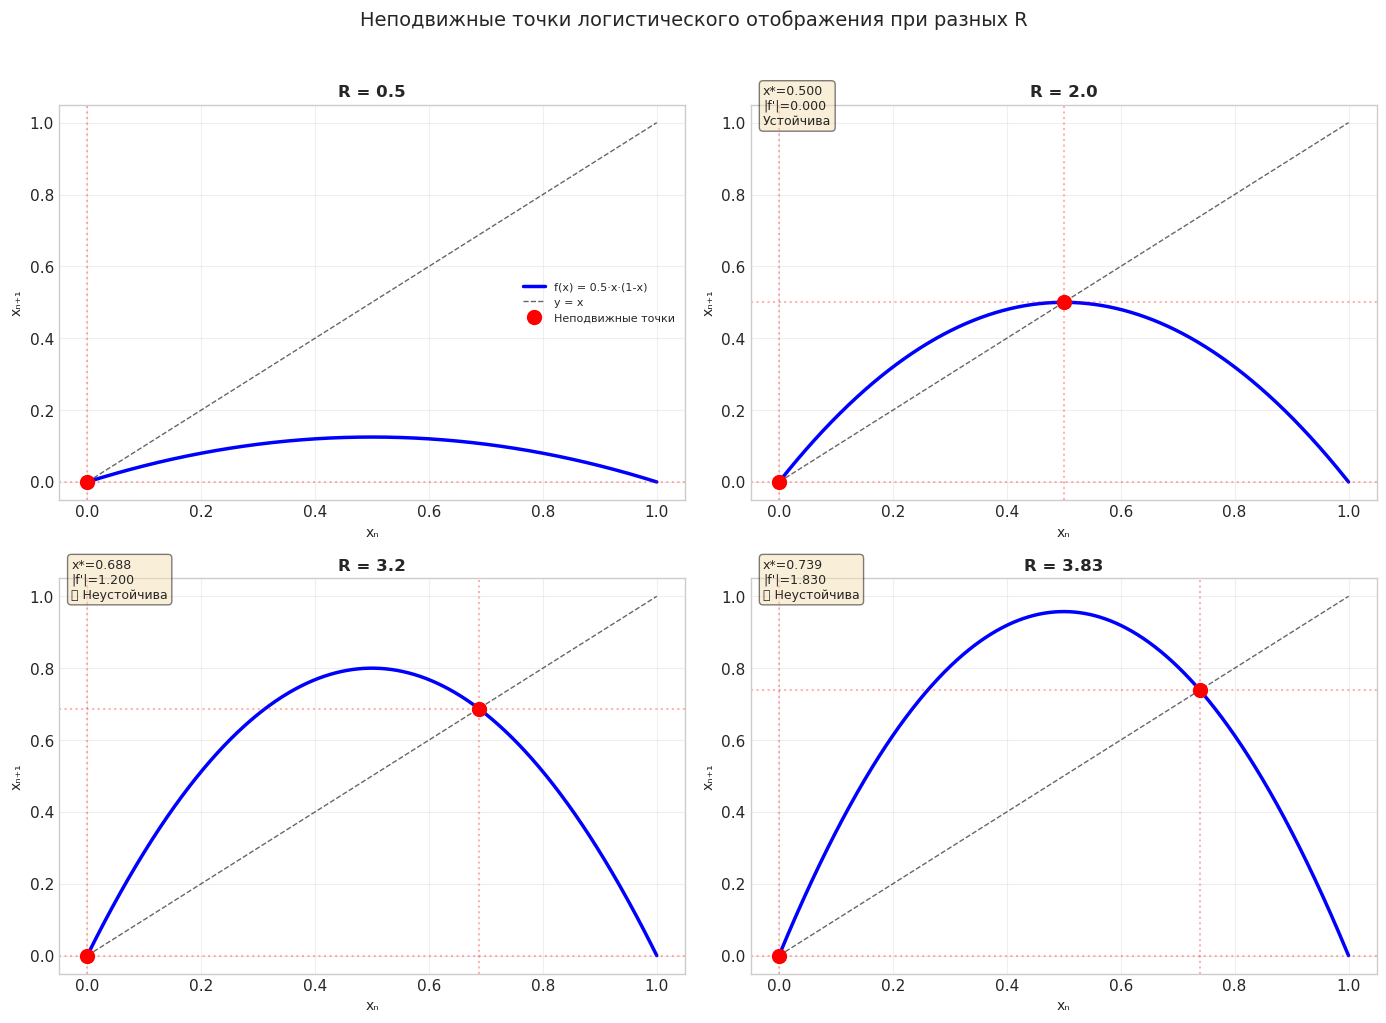

Область устойчивости неподвижной точки x* = 1 - 1/R

Условие: |f'(x*)| = |2-R| < 1 → устойчиво при 1 < R < 3

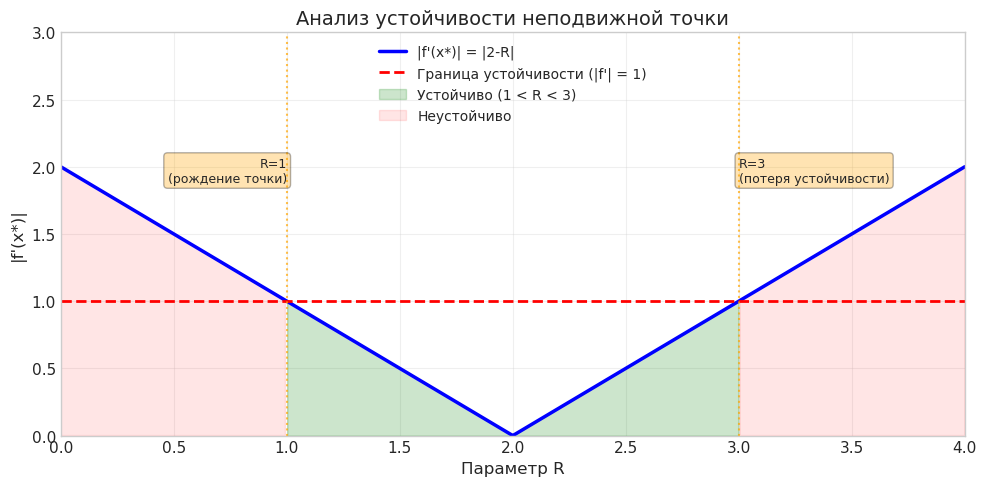

Цикл периода 2: графическое решение и бифуркация

При R > 3 неподвижная точка теряет устойчивость, рождается цикл периода 2

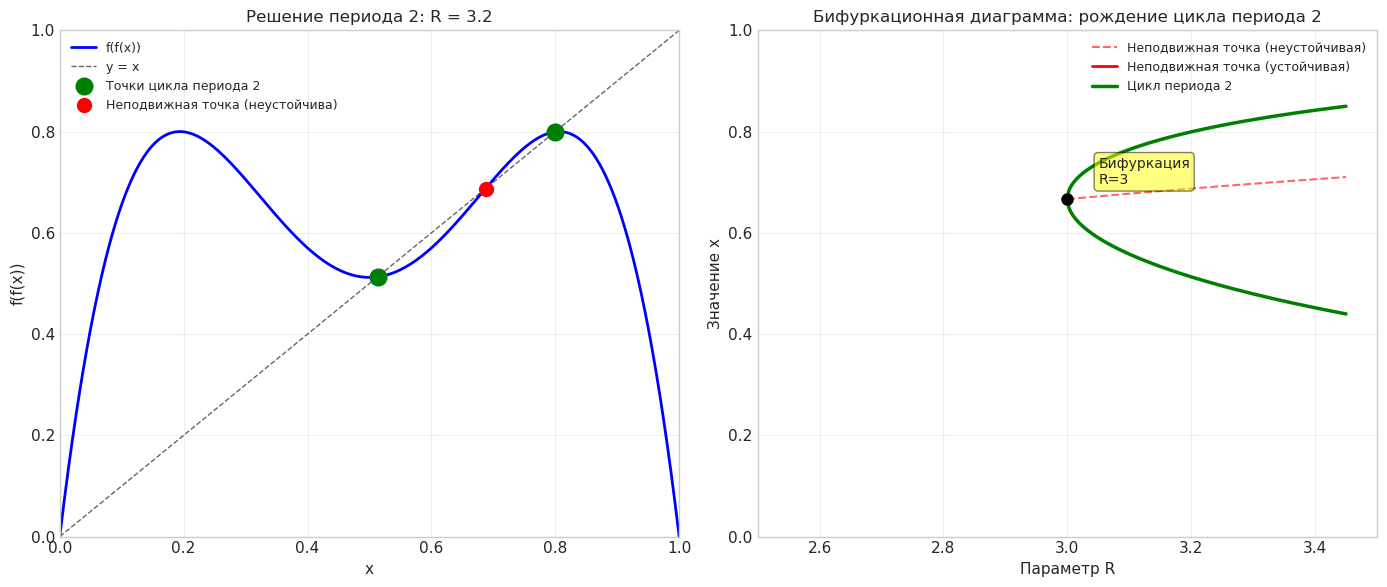

Сводная схема последовательности бифуркаций

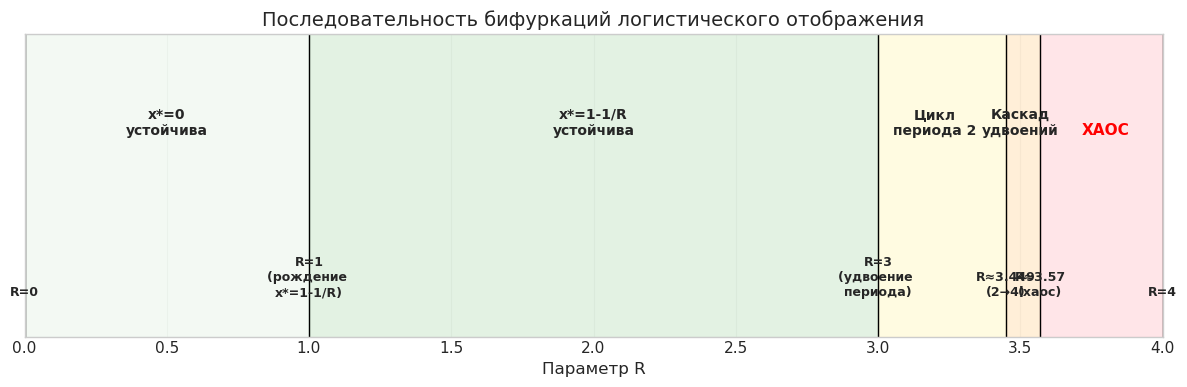

In [4]:
display(Markdown("ЗАДАНИЕ 4: Неподвижные точки и циклы периода 2"))

# Параметры для визуализации
R_values_demo = [0.5, 2.0, 3.2, 3.83]  # Разные режимы
x = np.linspace(0, 1, 1000)

# ГРАФИК 1: Функция f(x) и неподвижные точки для разных R
display(Markdown("Неподвижные точки: графическое решение"))
display(Markdown("Неподвижная точка — это пересечение графика f(x) с прямой y=x"))

fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10))
axes1 = axes1.flatten()

for idx, R in enumerate(R_values_demo):
    ax = axes1[idx]
    f_x = R*x *(1 - x)
    
    # График функции и диагонали
    ax.plot(x, f_x, 'b-', linewidth=2.5, label=f'f(x) = {R}·x·(1-x)')
    ax.plot(x, x, 'k--', linewidth=1, label='y = x', alpha=0.6)
    
    # Неподвижные точки
    fp1 = 0
    fp2 = 1 - 1/R if R > 1 else None
    
    ax.plot(fp1, fp1, 'ro', markersize=10, label='Неподвижные точки', zorder=5)
    ax.axvline(x=fp1, color='r', linestyle=':', alpha=0.3)
    ax.axhline(y=fp1, color='r', linestyle=':', alpha=0.3)
    
    if fp2 is not None and 0 <= fp2 <= 1:
        ax.plot(fp2, fp2, 'ro', markersize=10, zorder=5)
        ax.axvline(x=fp2, color='r', linestyle=':', alpha=0.3)
        ax.axhline(y=fp2, color='r', linestyle=':', alpha=0.3)
    
    # Стрелки, показывающие устойчивость (производная)
    if fp2 is not None and 0 <= fp2 <= 1:
        derivative = abs(R * (1 - 2*fp2))
        status = "Устойчива" if derivative < 1 else "❌ Неустойчива"
        ax.text(0.02, 0.95, f'x*={fp2:.3f}\n|f\'|={derivative:.3f}\n{status}', 
                transform=ax.transAxes, fontsize=9, 
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel('xₙ', fontsize=10)
    ax.set_ylabel('xₙ₊₁', fontsize=10)
    ax.set_title(f'R = {R}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=8)
plt.suptitle('Неподвижные точки логистического отображения при разных R', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


# ГРАФИК 2: Диаграмма устойчивости неподвижной точки
display(Markdown("Область устойчивости неподвижной точки x* = 1 - 1/R"))
display(Markdown("Условие: |f'(x*)| = |2-R| < 1 → устойчиво при 1 < R < 3"))

R_stability = np.linspace(0, 4, 500)
derivative_vals = np.abs(2 - R_stability)

fig2, ax2 = plt.subplots(figsize=(10, 5))

# График модуля производной
ax2.plot(R_stability, derivative_vals, 'b-', linewidth=2.5, label='|f\'(x*)| = |2-R|')
ax2.axhline(y=1, color='r', linestyle='--', linewidth=2, label='Граница устойчивости (|f\'| = 1)')

# Заливка областей
ax2.fill_between(R_stability, 0, derivative_vals, 
                 where=(derivative_vals < 1) & (R_stability > 1), 
                 color='green', alpha=0.2, 
                 label='Устойчиво (1 < R < 3)')
ax2.fill_between(R_stability, 0, derivative_vals, 
                 where=(derivative_vals >= 1) | (R_stability <= 1), 
                 color='red', alpha=0.1, 
                 label='Неустойчиво')

# Вертикальные линии бифуркаций
ax2.axvline(x=1, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.axvline(x=3, color='orange', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.text(1, ax2.get_ylim()[1]*0.9, 'R=1\n(рождение точки)', fontsize=9, 
         ha='right', bbox=dict(boxstyle='round', facecolor='orange', alpha=0.3))
ax2.text(3, ax2.get_ylim()[1]*0.9, 'R=3\n(потеря устойчивости)', fontsize=9, 
         ha='left', bbox=dict(boxstyle='round', facecolor='orange', alpha=0.3))
ax2.set_xlabel('Параметр R', fontsize=12)
ax2.set_ylabel('|f\'(x*)|', fontsize=12)
ax2.set_title('Анализ устойчивости неподвижной точки', fontsize=14)
ax2.set_xlim(0, 4)
ax2.set_ylim(0, 3)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=10)
plt.tight_layout()
plt.show()


# ГРАФИК 3: Рождение цикла периода 2 (бифуркация)
display(Markdown("Цикл периода 2: графическое решение и бифуркация"))
display(Markdown("При R > 3 неподвижная точка теряет устойчивость, рождается цикл периода 2"))

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))

# Левая часть: f(f(x)) для R=3.2
R_cycle = 3.2
f_x = R_cycle * x * (1 - x)
ff_x = R_cycle * f_x * (1 - f_x)  # f(f(x))

ax = axes3[0]
ax.plot(x, ff_x, 'b-', linewidth=2, label='f(f(x))')
ax.plot(x, x, 'k--', linewidth=1, label='y = x', alpha=0.6)

# Точки цикла периода 2 (аналитически)
discriminant = np.sqrt((R_cycle - 3) * (R_cycle + 1))
cycle_p1 = (R_cycle + 1 + discriminant) / (2 * R_cycle)
cycle_p2 = (R_cycle + 1 - discriminant) / (2 * R_cycle)

ax.plot([cycle_p1, cycle_p2], [cycle_p1, cycle_p2], 'go', markersize=12, 
        label='Точки цикла периода 2', zorder=5)

# Неподвижная точка для сравнения
fp = 1 - 1/R_cycle
ax.plot(fp, fp, 'ro', markersize=10, label='Неподвижная точка (неустойчива)', zorder=5)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('x', fontsize=11)
ax.set_ylabel('f(f(x))', fontsize=11)
ax.set_title(f'Решение периода 2: R = {R_cycle}', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

# Правая часть: Бифуркационная ветвь цикла периода 2
R_branch = np.linspace(3, 3.45, 200)
cycle_branch_plus = (R_branch + 1 + np.sqrt((R_branch - 3) * (R_branch + 1))) / (2 * R_branch)
cycle_branch_minus = (R_branch + 1 - np.sqrt((R_branch - 3) * (R_branch + 1))) / (2 * R_branch)

ax2 = axes3[1]
# Ветвь неподвижной точки
fp_branch = 1 - 1/R_branch
ax2.plot(R_branch, fp_branch, 'r--', linewidth=1.5, label='Неподвижная точка (неустойчивая)', alpha=0.6)
ax2.plot(R_branch[R_branch<3], 1-1/R_branch[R_branch<3], 'r-', linewidth=2, label='Неподвижная точка (устойчивая)')

# Ветви цикла периода 2
ax2.plot(R_branch, cycle_branch_plus, 'g-', linewidth=2.5, label='Цикл периода 2')
ax2.plot(R_branch, cycle_branch_minus, 'g-', linewidth=2.5)

# Точка бифуркации
ax2.plot(3, 2/3, 'ko', markersize=8, zorder=5)
ax2.text(3.05, 2/3 + 0.03, 'Бифуркация\nR=3', fontsize=10, 
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
ax2.set_xlabel('Параметр R', fontsize=11)
ax2.set_ylabel('Значение x', fontsize=11)
ax2.set_title('Бифуркационная диаграмма: рождение цикла периода 2', fontsize=12)
ax2.set_xlim(2.5, 3.5)
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()


# ГРАФИК 4: Полная схема бифуркаций (сводная)
display(Markdown("Сводная схема последовательности бифуркаций"))

fig4, ax4 = plt.subplots(figsize=(12, 4))

# Горизонтальная ось параметров
bifurcation_points = [0, 1, 3, 1+np.sqrt(6), 3.57, 4]
bifurcation_labels = ['R=0', 'R=1\n(рождение \nx*=1-1/R)', 'R=3\n(удвоение \nпериода)', 
                      'R≈3.449\n(2→4)', 'R≈3.57\n(хаос)', 'R=4']
colors = ['#e8f5e9', '#c8e6c9', '#fff9c4', '#ffe0b2', '#ffcdd2', '#f5f5f5']

for i in range(len(bifurcation_points)-1):
    ax4.axvspan(bifurcation_points[i], bifurcation_points[i+1], 
                color=colors[i], alpha=0.5)

# Вертикальные линии
for bp, label in zip(bifurcation_points, bifurcation_labels):
    ax4.axvline(x=bp, color='k', linestyle='-', linewidth=1)
    ax4.text(bp, -0.3, label, ha='center', fontsize=9, fontweight='bold')

# Стрелки и подписи режимов
ax4.text(0.5, 0.5, 'x*=0\nустойчива', ha='center', fontsize=10, fontweight='bold')
ax4.text(2, 0.5, 'x*=1-1/R\nустойчива', ha='center', fontsize=10, fontweight='bold')
ax4.text(3.2, 0.5, 'Цикл\nпериода 2', ha='center', fontsize=10, fontweight='bold')
ax4.text(3.5, 0.5, 'Каскад\nудвоений', ha='center', fontsize=10, fontweight='bold')
ax4.text(3.8, 0.5, 'ХАОС', ha='center', fontsize=11, fontweight='bold', color='red')
ax4.set_xlim(0, 4)
ax4.set_ylim(-0.5, 1)
ax4.set_xlabel('Параметр R', fontsize=12)
ax4.set_yticks([])
ax4.set_title('Последовательность бифуркаций логистического отображения', fontsize=14)
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

ЗАДАНИЕ 5: Паутинные диаграммы (Кёнигса-Ламея)

Случай а) R = 2.5: Устойчивая неподвижная точка

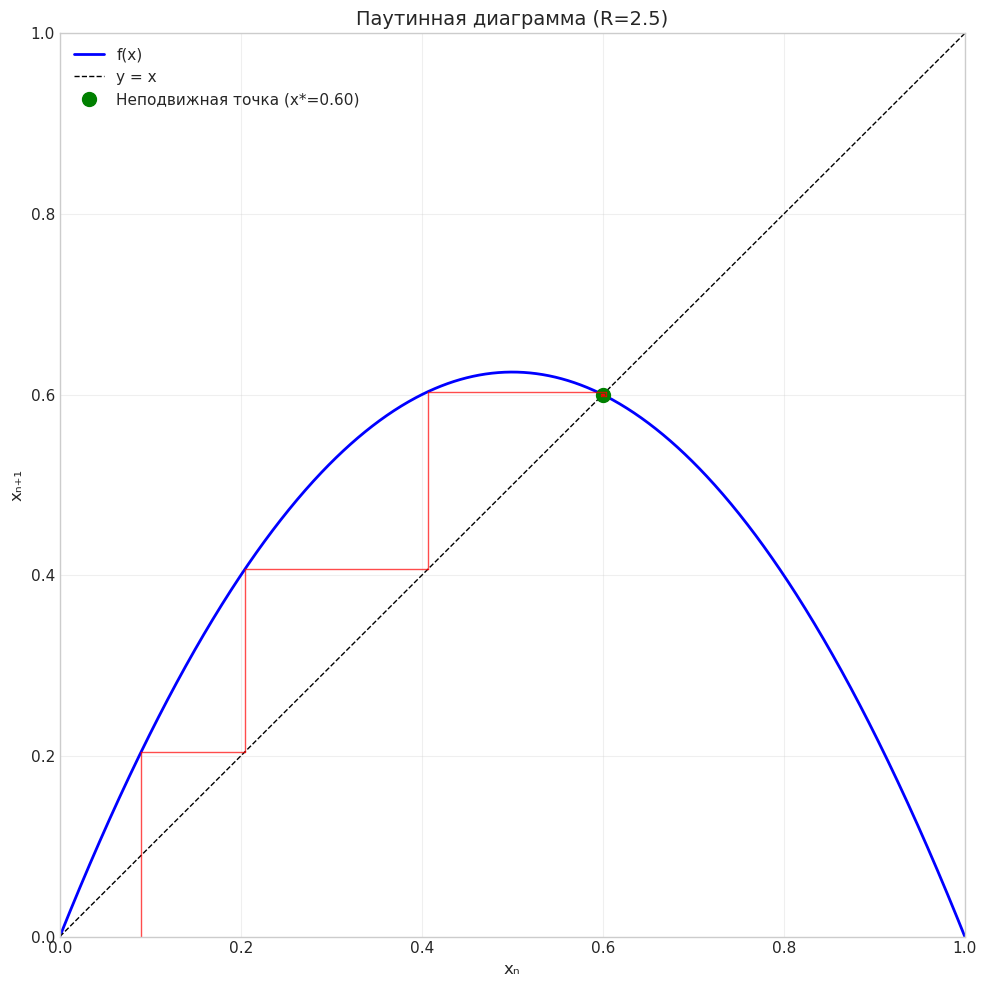

### Случай б) R = 3.2: Цикл периода 2

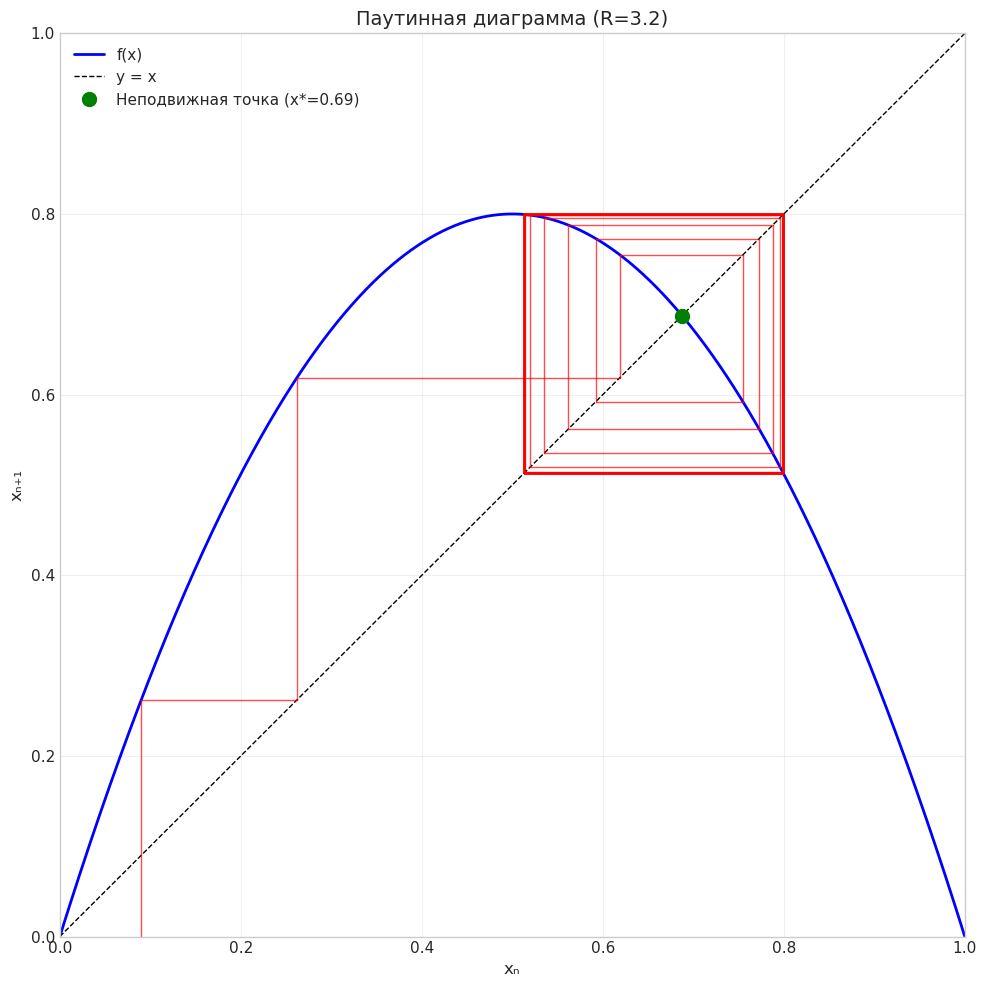

Случай в) R = 3.83: Сложная динамика (Окно периода 3)

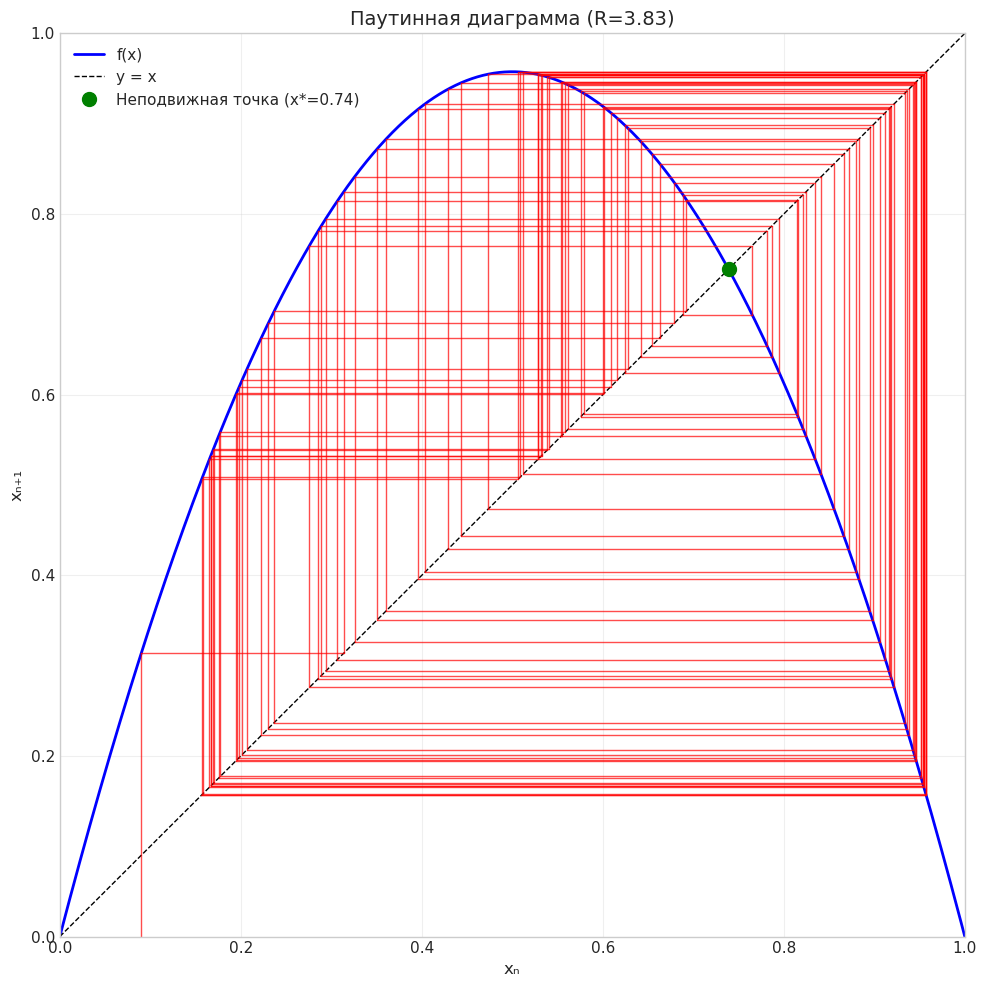

In [5]:
def cobweb_plot(x0, n_iterations, R, title_suffix=""):
    """Построение паутинной диаграммы для логистического отображения"""
    x = np.linspace(0, 1, 1000)
    y = R * x * (1 - x)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.plot(x, y, 'b-', linewidth=2, label='f(x)')
    ax.plot(x, x, 'k--', linewidth=1, label='y = x')
    
    # Добавим маркер для неподвижной точки для наглядности
    fp = 1 - 1/R
    if 0 <= fp <= 1:
        ax.plot(fp, fp, 'go', markersize=10, label=f'Неподвижная точка (x*={fp:.2f})')

    # Построение "паутины"
    xi = x0
    yi = 0
    for i in range(n_iterations):
        x_new = R * xi * (1 - xi)
        # Вертикальный отрезок
        ax.plot([xi, xi], [yi, x_new], 'r-', linewidth=1, alpha=0.7)
        # Горизонтальный отрезок
        ax.plot([xi, x_new], [x_new, x_new], 'r-', linewidth=1, alpha=0.7)
        xi = x_new
        yi = x_new
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('xₙ', fontsize=12)
    ax.set_ylabel('xₙ₊₁', fontsize=12)
    ax.set_title(f'Паутинная диаграмма {title_suffix}', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    return fig, ax


display(Markdown("ЗАДАНИЕ 5: Паутинные диаграммы (Кёнигса-Ламея)"))

# а): Устойчивая неподвижная точка (R = 2.5)
display(Markdown("Случай а) R = 2.5: Устойчивая неподвижная точка"))
fig1, ax1 = cobweb_plot(x0, 50, R=2.5, title_suffix="(R=2.5)")
plt.show()

# б): Цикл периода 2 (R = 3.2)
display(Markdown("### Случай б) R = 3.2: Цикл периода 2"))
fig2, ax2 = cobweb_plot(x0, 50, R=3.2, title_suffix="(R=3.2)")
plt.show()

# в): Сложная динамика (R = 3.83)
display(Markdown("Случай в) R = 3.83: Сложная динамика (Окно периода 3)"))
fig3, ax3 = cobweb_plot(x0, 100, R=3.83, title_suffix="(R=3.83)")
plt.show()

ЗАДАНИЕ 6: Чувствительность к начальным условиям (хаос)

Параметры: r = 3.9, x₀ = 0.09, возмущение δ = 1e-08
Формула: x(n+1) = r * x(n) * (1 - x(n))


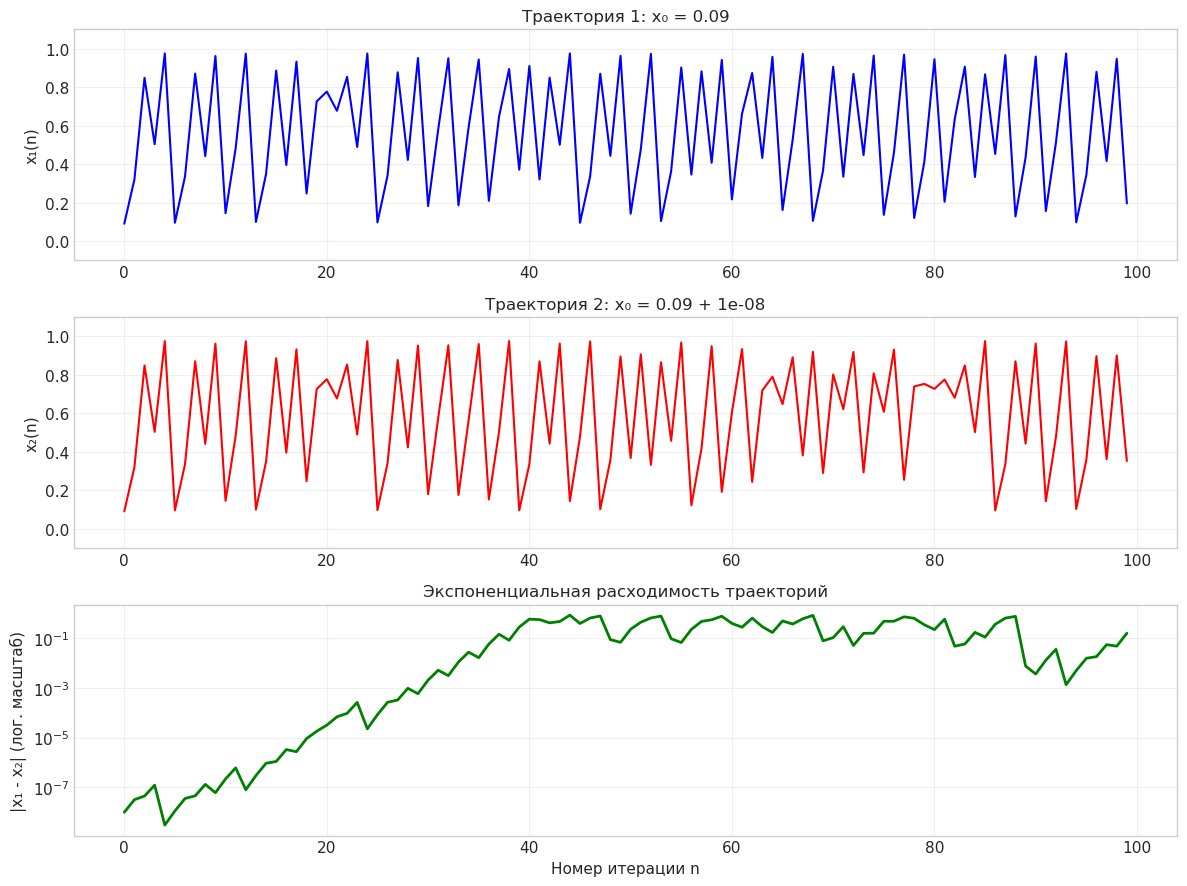


РЕЗУЛЬТАТЫ:
- Начальная разность: 1e-08 (микроскопическая)
- Разность превысила 0.1 на итерации:37
- Конечная разность: 0.155807 (траектории стали совершенно разными)

ВЫВОД:
- Наблюдается экспоненциальный рост ошибки.
- Несмотря на почти идентичный старт, через ~37 итераций предсказать состояние системы по первой траектории невозможно.
- Это и есть "Эффект бабочки" — свойство хаотических систем.
    

In [6]:
display(Markdown("ЗАДАНИЕ 6: Чувствительность к начальным условиям (хаос)"))

# Для хаоса используем каноническую форму: x_{n+1} = r * x * (1 - x)
# В этой форме хаос наступает при r > 3.57, а полная карта [0,1] до r=4.
def logistic_map_chaos(x, r):
    return r * x * (1 - x)

r_chaos = 3.9
delta = 1e-8  # Чуть увеличим возмущение, чтобы эффект был виден быстрее

print(f"Параметры: r = {r_chaos}, x₀ = {x0}, возмущение δ = {delta}")
print("Формула: x(n+1) = r * x(n) * (1 - x(n))")

n_iterations = 100

# Две траектории
x1 = np.zeros(n_iterations)
x2 = np.zeros(n_iterations)
x1[0] = x0
x2[0] = x0 + delta

for n in range(n_iterations - 1):
    x1[n+1] = logistic_map_chaos(x1[n], r_chaos)
    x2[n+1] = logistic_map_chaos(x2[n], r_chaos)

# Разность траекторий
diff = np.abs(x1 - x2)

# Визуализация
fig, axes = plt.subplots(3, 1, figsize=(12, 9))

# 1. Первая траектория
axes[0].plot(range(n_iterations), x1, 'b-', linewidth=1.5)
axes[0].set_ylabel('x₁(n)', fontsize=11)
axes[0].set_title(f'Траектория 1: x₀ = {x0}', fontsize=12)
axes[0].set_ylim(-0.1, 1.1) # Фиксируем пределы
axes[0].grid(True, alpha=0.3)

# 2. Вторая траектория
axes[1].plot(range(n_iterations), x2, 'r-', linewidth=1.5)
axes[1].set_ylabel('x₂(n)', fontsize=11)
axes[1].set_title(f'Траектория 2: x₀ = {x0} + {delta:.0e}', fontsize=12)
axes[1].set_ylim(-0.1, 1.1) # Фиксируем пределы
axes[1].grid(True, alpha=0.3)

# 3. Разность (логарифмическая шкала)
axes[2].semilogy(range(n_iterations), diff + 1e-16, 'g-', linewidth=2)
axes[2].set_xlabel('Номер итерации n', fontsize=11)
axes[2].set_ylabel('|x₁ - x₂| (лог. масштаб)', fontsize=11)
axes[2].set_title('Экспоненциальная расходимость траекторий', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ расходимости
threshold = 0.1
diverge_idx = np.where(diff > threshold)[0]
if len(diverge_idx) > 0:
    first_diverge = diverge_idx[0]
    
    display(Markdown(f"""
РЕЗУЛЬТАТЫ:
- Начальная разность: {delta:.0e} (микроскопическая)
- Разность превысила {threshold} на итерации:{first_diverge}
- Конечная разность: {diff[-1]:.6f} (траектории стали совершенно разными)

ВЫВОД:
- Наблюдается экспоненциальный рост ошибки.
- Несмотря на почти идентичный старт, через ~{first_diverge} итераций предсказать состояние системы по первой траектории невозможно.
- Это и есть "Эффект бабочки" — свойство хаотических систем.
    """))

Бифуркационная диаграмма

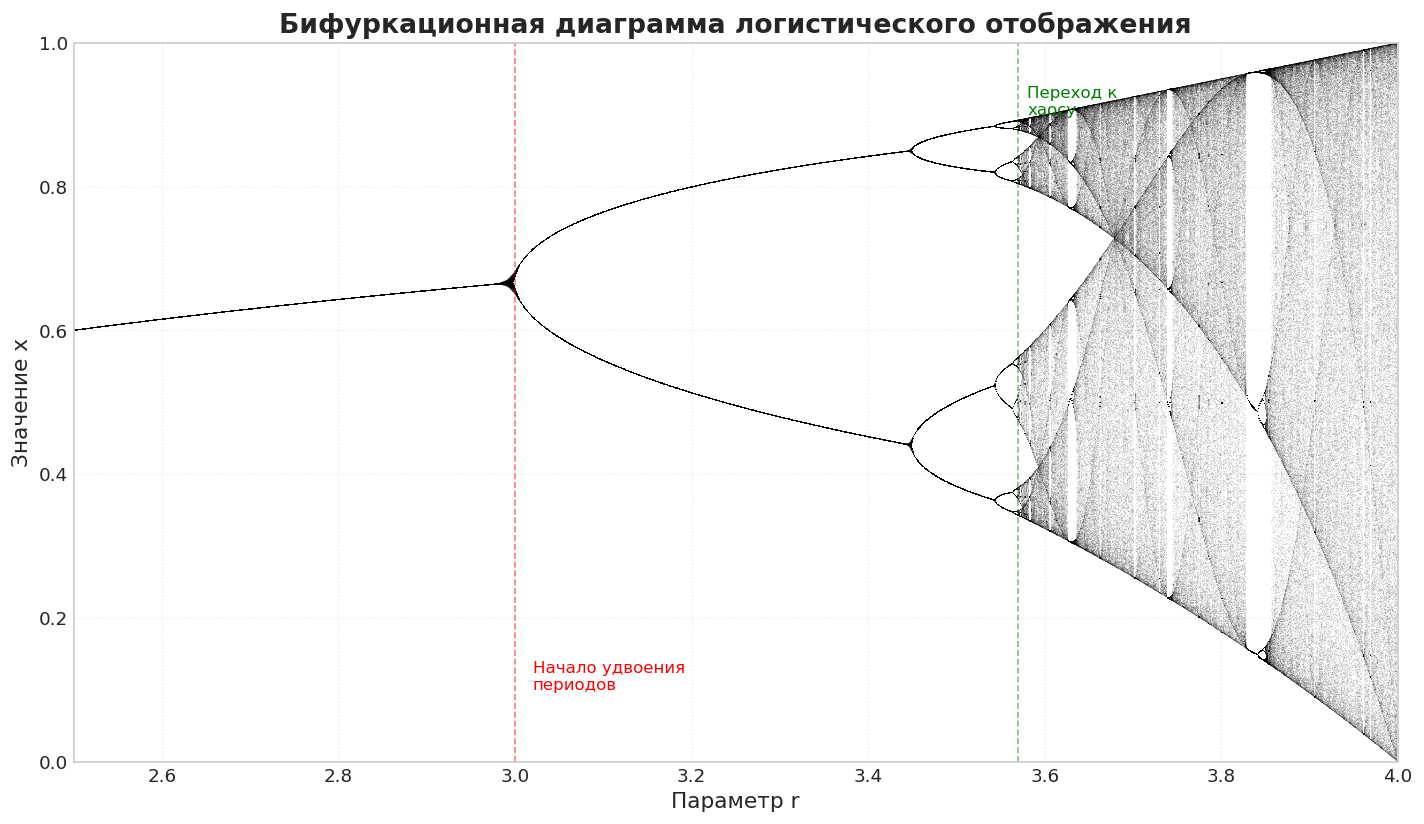


На графике:
1. r < 3.0: Одна устойчивая точка (синяя линия сливается в одну).
2. r ≈ 3.0: Бифуркация — линия раздваивается (период 2).
3. r ≈ 3.45: Еще одно раздвоение (период 4).
4. r > 3.57: Сплошная заштрихованная область — это ХАОС. Значения скачут непредсказуемо, но остаются в рамках [0, 1].
5. Внутри хаоса видны белые "дырки" — это окна периодичности (временное возвращение порядка).


In [8]:
display(Markdown("Бифуркационная диаграмма"))

r_min, r_max = 2.5, 4.0
num_r_steps = 1500 # Точность по горизонтали
n_skip = 200  # Пропускаем переходный процесс
n_plot = 1000 # Сколько точек рисуем для каждого r

x = 0.5 # Начальное условие (от 0 до 1)

# Массивы для хранения всех точек
all_x = []
all_r = []

# 2. Основной цикл вычислений
r_values = np.linspace(r_min, r_max, num_r_steps)

for r in r_values:
    # Сброс начального условия для нового r (или продолжаем с текущего)
    x = 0.5 
    # Пропускаем переходный процесс (чтобы попасть на аттрактор)
    for _ in range(n_skip):
        x = r * x * (1 - x)
    
    # Собираем точки аттрактора
    for _ in range(n_plot):
        x = r * x * (1 - x)
        all_x.append(x)
        all_r.append(r)

# 3. Построение графика
plt.figure(figsize=(12, 7), dpi=120)

# scatter для точечного контроля размера и прозрачности
plt.scatter(all_r, all_x, s=0.1, c='black', alpha=0.4, edgecolors='none')

# Оформление
plt.title('Бифуркационная диаграмма логистического отображения', fontsize=16, fontweight='bold')
plt.xlabel('Параметр r', fontsize=13)
plt.ylabel('Значение x', fontsize=13)
plt.xlim(r_min, r_max)
plt.ylim(0, 1) # Жестко ограничиваем, так как x не может быть больше 1
plt.grid(True, linestyle=':', alpha=0.4)

# Добавляем поясняющие зоны
plt.axvline(x=3.0, color='r', linestyle='--', alpha=0.5, linewidth=1)
plt.text(3.02, 0.1, 'Начало удвоения\nпериодов', fontsize=10, color='red')

plt.axvline(x=3.57, color='g', linestyle='--', alpha=0.5, linewidth=1)
plt.text(3.58, 0.9, 'Переход к\nхаосу', fontsize=10, color='green')

plt.tight_layout()
plt.show()

display(Markdown("""
На графике:
1. r < 3.0: Одна устойчивая точка (синяя линия сливается в одну).
2. r ≈ 3.0: Бифуркация — линия раздваивается (период 2).
3. r ≈ 3.45: Еще одно раздвоение (период 4).
4. r > 3.57: Сплошная заштрихованная область — это ХАОС. Значения скачут непредсказуемо, но остаются в рамках [0, 1].
5. Внутри хаоса видны белые "дырки" — это окна периодичности (временное возвращение порядка).
"""))